In [1]:
import sys
import os
import torch
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Add parent directory to sys.path to import custom src modules
sys.path.append('../')

from src.features import prepare_train_val_test_splits
from src.dataset import create_dataloaders
from src.models.lstm_model import EnergyLSTM

# Set compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Load Data Splits and Scalers
train_scaled, val_scaled, test_scaled, target_scaler, feature_scaler = prepare_train_val_test_splits(
    df_path='../data/processed/processed_aep.csv'
)

# Load saved scalers from disk
target_scaler = joblib.load('../models/target_scaler.pkl')

# 2. Create Test DataLoader
LOOKBACK = 24
FORECAST_HORIZON = 1
BATCH_SIZE = 64

_, _, test_loader = create_dataloaders(
    train_scaled, val_scaled, test_scaled,
    lookback=LOOKBACK, forecast_horizon=FORECAST_HORIZON, batch_size=BATCH_SIZE
)

# 3. Load Model Architecture & Weights
num_features = test_scaled.shape[1]
model = EnergyLSTM(
    input_size=num_features,
    hidden_size=64,
    num_layers=2,
    output_size=FORECAST_HORIZON
).to(device)

model.load_state_dict(torch.load('../models/best_lstm_model.pth', map_location=device))
model.eval()
print("Successfully loaded model weights from models/best_lstm_model.pth")

Using device: cuda
Successfully loaded model weights from models/best_lstm_model.pth


C:\Users\amann\AppData\Local\Temp\ipykernel_39108\302338122.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../models/best_lstm_model.

In [2]:
predictions_scaled = []
actuals_scaled = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_pred = model(x_batch)
        
        predictions_scaled.append(y_pred.cpu().numpy())
        actuals_scaled.append(y_batch.numpy())

# Flatten arrays
predictions_scaled = np.vstack(predictions_scaled)
actuals_scaled = np.vstack(actuals_scaled)

# Inverse transform scaled values back to real Megawatts (MW)
predictions_mw = target_scaler.inverse_transform(predictions_scaled)
actuals_mw = target_scaler.inverse_transform(actuals_scaled)

# -------------------------------------------------------------
# Compute Regression Metrics
# -------------------------------------------------------------
rmse = np.sqrt(mean_squared_error(actuals_mw, predictions_mw))
mae = mean_absolute_error(actuals_mw, predictions_mw)
mape = mean_absolute_percentage_error(actuals_mw, predictions_mw) * 100

print("=" * 45)
print("          TEST SET EVALUATION METRICS        ")
print("=" * 45)
print(f"RMSE (Root Mean Squared Error):   {rmse:.2f} MW")
print(f"MAE  (Mean Absolute Error):     {mae:.2f} MW")
print(f"MAPE (Mean Absolute % Error):   {mape:.2f}%")
print("=" * 45)

          TEST SET EVALUATION METRICS        
RMSE (Root Mean Squared Error):   154.77 MW
MAE  (Mean Absolute Error):     116.41 MW
MAPE (Mean Absolute % Error):   0.78%


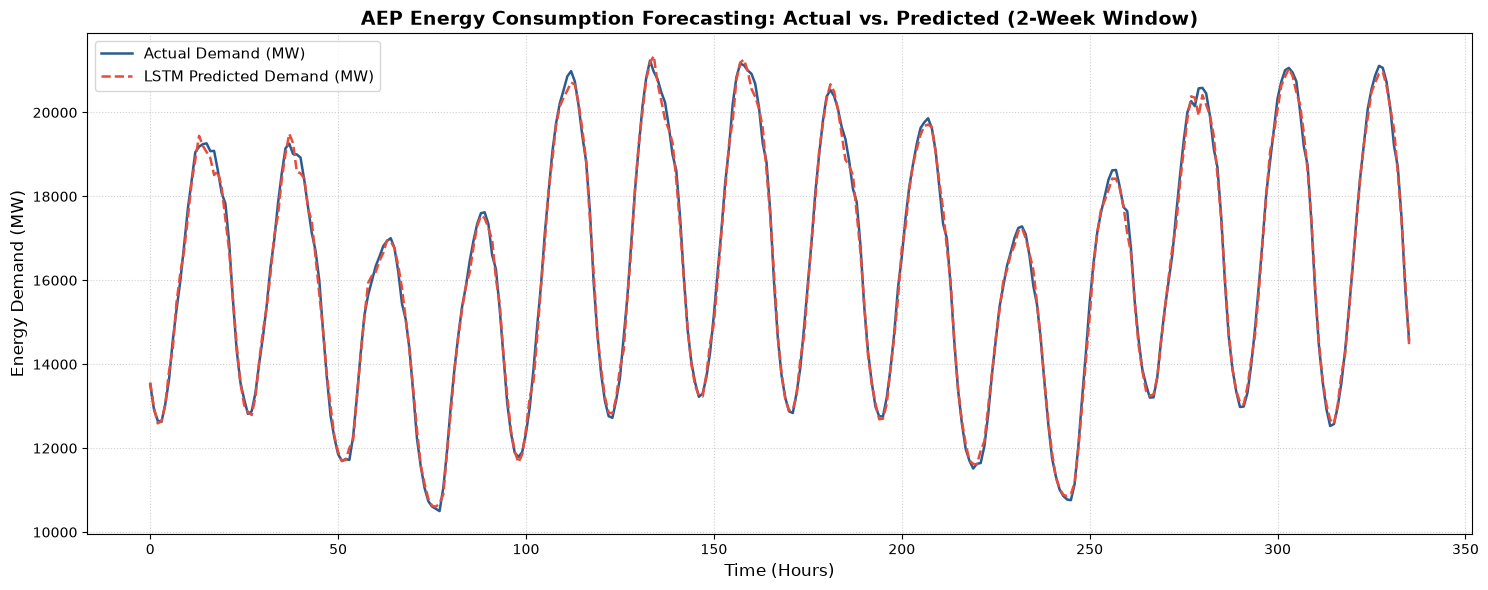

In [3]:
plt.figure(figsize=(15, 6))

# Display a 2-week window (24 * 14 = 336 hours)
sample_size = 336 

plt.plot(actuals_mw[:sample_size], label='Actual Demand (MW)', color='#2b5c8f', linewidth=1.8)
plt.plot(predictions_mw[:sample_size], label='LSTM Predicted Demand (MW)', color='#e74c3c', linestyle='--', linewidth=1.8)

plt.title('AEP Energy Consumption Forecasting: Actual vs. Predicted (2-Week Window)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Energy Demand (MW)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

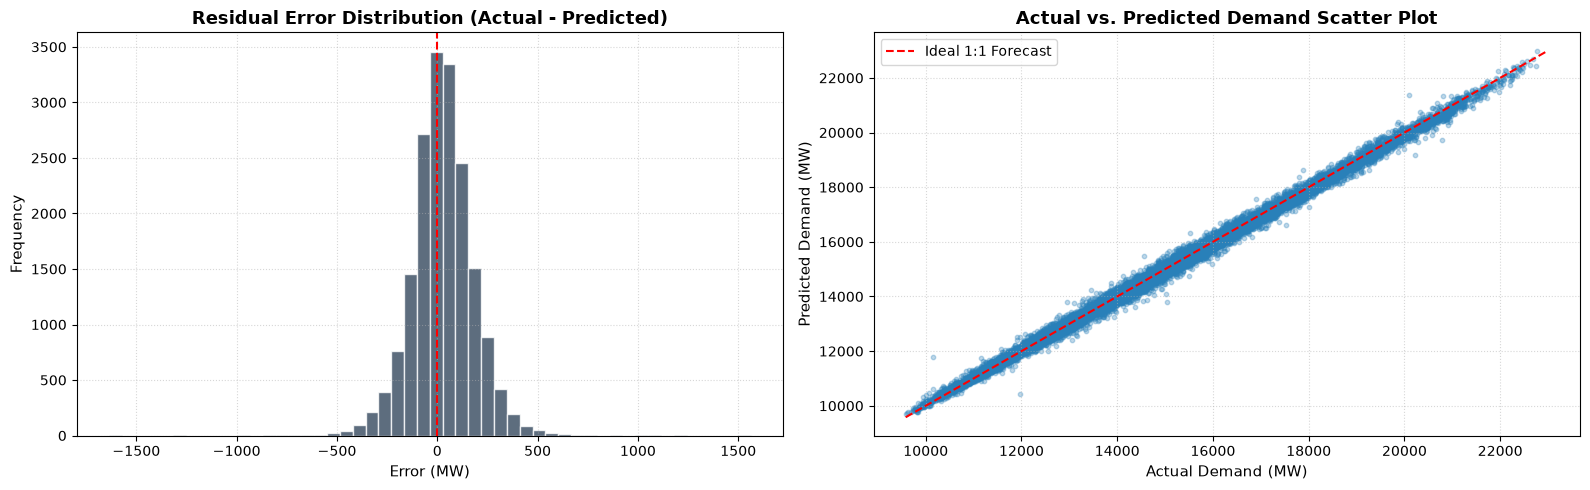

In [4]:
residuals = actuals_mw - predictions_mw

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Residual Histogram
axes[0].hist(residuals, bins=50, color='#34495e', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Error Distribution (Actual - Predicted)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Error (MW)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.5)

# 2. Scatter Plot: Actual vs Predicted
axes[1].scatter(actuals_mw, predictions_mw, alpha=0.3, color='#2980b9', s=10)
min_val = min(actuals_mw.min(), predictions_mw.min())
max_val = max(actuals_mw.max(), predictions_mw.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal 1:1 Forecast')

axes[1].set_title('Actual vs. Predicted Demand Scatter Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Demand (MW)', fontsize=11)
axes[1].set_ylabel('Predicted Demand (MW)', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()